In [2]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
)

from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [3]:
import sklearn
import xgboost

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

pandas: 2.3.3
numpy: 2.3.5
scikit-learn: 1.7.2
xgboost: 3.3.0


In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_CV_FOLDS = 5

OUTPUT_DIRECTORY = Path("automl_output")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [5]:
def load_dataset(csv_path):
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {csv_path.resolve()}"
        )

    if csv_path.suffix.lower() != ".csv":
        raise ValueError(
            "AutoML Engine V1 currently supports CSV files only."
        )

    dataframe = pd.read_csv(csv_path)

    if dataframe.empty:
        raise ValueError("The dataset is empty.")

    # Clean spaces around column names
    dataframe.columns = dataframe.columns.str.strip()

    # Prevent duplicate column names
    if dataframe.columns.duplicated().any():
        duplicated_columns = dataframe.columns[
            dataframe.columns.duplicated()
        ].tolist()

        raise ValueError(
            f"Duplicate column names found: {duplicated_columns}"
        )

    return dataframe

In [6]:
def inspect_dataset(dataframe, target_column):
    if target_column not in dataframe.columns:
        raise ValueError(
            f"Target column '{target_column}' was not found.\n"
            f"Available columns: {dataframe.columns.tolist()}"
        )

    column_report = pd.DataFrame({
        "Data Type": dataframe.dtypes.astype(str),
        "Missing Count": dataframe.isnull().sum(),
        "Missing Percentage": (
            dataframe.isnull().mean() * 100
        ).round(2),
        "Unique Values": dataframe.nunique(dropna=False)
    })

    column_report = column_report.sort_values(
        by="Missing Percentage",
        ascending=False
    )

    constant_columns = [
        column
        for column in dataframe.columns
        if dataframe[column].nunique(dropna=False) <= 1
    ]

    possible_id_columns = []

    for column in dataframe.columns:
        if column == target_column:
            continue

        unique_ratio = (
            dataframe[column].nunique(dropna=False)
            / len(dataframe)
        )

        if unique_ratio >= 0.95:
            possible_id_columns.append(column)

    dataset_summary = {
        "rows": int(dataframe.shape[0]),
        "columns": int(dataframe.shape[1]),
        "target_column": target_column,
        "target_unique_values": int(
            dataframe[target_column].nunique(dropna=True)
        ),
        "duplicate_rows": int(
            dataframe.duplicated().sum()
        ),
        "total_missing_values": int(
            dataframe.isnull().sum().sum()
        ),
        "constant_columns": constant_columns,
        "possible_id_columns": possible_id_columns
    }

    return dataset_summary, column_report

In [7]:
# This produces information that will later appear in the AutoML report.

In [8]:
def clean_dataset(
    dataframe,
    target_column,
    columns_to_drop=None,
    remove_duplicates=True
):
    cleaned_dataframe = dataframe.copy()
    cleaning_actions = []

    # Remove duplicate rows
    if remove_duplicates:
        duplicate_count = int(
            cleaned_dataframe.duplicated().sum()
        )

        if duplicate_count > 0:
            cleaned_dataframe = (
                cleaned_dataframe
                .drop_duplicates()
                .reset_index(drop=True)
            )

            cleaning_actions.append(
                f"Removed {duplicate_count} duplicate rows."
            )

    # Remove rows where the target is missing
    missing_target_count = int(
        cleaned_dataframe[target_column]
        .isnull()
        .sum()
    )

    if missing_target_count > 0:
        cleaned_dataframe = (
            cleaned_dataframe
            .dropna(subset=[target_column])
            .reset_index(drop=True)
        )

        cleaning_actions.append(
            f"Removed {missing_target_count} rows "
            "with missing target values."
        )

    # Remove constant feature columns
    constant_columns = [
        column
        for column in cleaned_dataframe.columns
        if (
            column != target_column
            and cleaned_dataframe[column]
            .nunique(dropna=False) <= 1
        )
    ]

    if constant_columns:
        cleaned_dataframe = cleaned_dataframe.drop(
            columns=constant_columns
        )

        cleaning_actions.append(
            f"Removed constant columns: {constant_columns}"
        )

    # Remove manually selected columns, such as IDs
    if columns_to_drop:
        valid_columns_to_drop = [
            column
            for column in columns_to_drop
            if (
                column in cleaned_dataframe.columns
                and column != target_column
            )
        ]

        if valid_columns_to_drop:
            cleaned_dataframe = cleaned_dataframe.drop(
                columns=valid_columns_to_drop
            )

            cleaning_actions.append(
                "Removed manually selected columns: "
                f"{valid_columns_to_drop}"
            )

    if cleaned_dataframe.empty:
        raise ValueError(
            "No rows remain after dataset cleaning."
        )

    if not cleaning_actions:
        cleaning_actions.append(
            "No row or column cleaning was required."
        )

    return cleaned_dataframe, cleaning_actions

In [9]:
# Cleaning actions are recorded so the customer can see exactly what the engine changed.

In [10]:
def separate_features_and_target(
    dataframe,
    target_column
):
    if target_column not in dataframe.columns:
        raise ValueError(
            f"Target column '{target_column}' was not found."
        )

    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column].copy()

    if X.shape[1] == 0:
        raise ValueError(
            "No feature columns remain after removing the target."
        )

    return X, y

In [11]:
# X contains model inputs, while y contains the answer the model learns to predict.

In [12]:
def detect_task_type(
    target,
    classification_unique_limit=20,
    classification_ratio_limit=0.05
):
    unique_count = int(
        target.nunique(dropna=True)
    )

    unique_ratio = unique_count / len(target)

    is_text = (
        target.dtype == "object"
        or str(target.dtype).startswith("category")
    )

    is_boolean = target.dtype == bool

    if (
        is_text
        or is_boolean
        or unique_count <= classification_unique_limit
        or unique_ratio <= classification_ratio_limit
    ):
        return "classification"

    return "regression"

In [14]:
# Task detection is a heuristic, so the future interface should allow users to override it.

In [15]:
def prepare_target(target, task_type):
    if task_type == "classification":
        target_encoder = LabelEncoder()

        encoded_values = target_encoder.fit_transform(
            target
        )

        prepared_target = pd.Series(
            encoded_values,
            index=target.index,
            name=target.name
        )

        target_information = {
            "number_of_classes": int(
                len(target_encoder.classes_)
            ),
            "classes": (
                target_encoder.classes_.tolist()
            ),
            "class_mapping": {
                str(class_name): int(encoded_value)
                for class_name, encoded_value in zip(
                    target_encoder.classes_,
                    target_encoder.transform(
                        target_encoder.classes_
                    )
                )
            }
        }

        return (
            prepared_target,
            target_encoder,
            target_information
        )

    if task_type == "regression":
        prepared_target = pd.to_numeric(
            target,
            errors="coerce"
        )

        invalid_count = int(
            prepared_target.isnull().sum()
        )

        if invalid_count > 0:
            raise ValueError(
                "Regression target contains "
                f"{invalid_count} non-numeric or missing values."
            )

        target_information = {
            "minimum": float(prepared_target.min()),
            "maximum": float(prepared_target.max()),
            "mean": float(prepared_target.mean()),
            "median": float(prepared_target.median())
        }

        return (
            prepared_target,
            None,
            target_information
        )

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [16]:
# Classification labels are encoded into integers, while regression targets remain continuous numbers.

In [17]:
def detect_feature_types(
    dataframe,
    categorical_unique_limit=15,
    categorical_ratio_limit=0.05
):
    numerical_columns = []
    categorical_columns = []

    for column in dataframe.columns:
        series = dataframe[column]

        unique_count = int(
            series.nunique(dropna=True)
        )

        unique_ratio = (
            unique_count / max(len(series), 1)
        )

        is_text = (
            series.dtype == "object"
            or str(series.dtype).startswith("category")
        )

        is_boolean = series.dtype == bool

        is_low_cardinality_numeric = (
            pd.api.types.is_numeric_dtype(series)
            and unique_count <= categorical_unique_limit
            and unique_ratio <= categorical_ratio_limit
        )

        if (
            is_text
            or is_boolean
            or is_low_cardinality_numeric
        ):
            categorical_columns.append(column)
        else:
            numerical_columns.append(column)

    detected_columns = set(
        numerical_columns + categorical_columns
    )

    missing_columns = (
        set(dataframe.columns) - detected_columns
    )

    if missing_columns:
        raise ValueError(
            "Could not detect feature type for: "
            f"{sorted(missing_columns)}"
        )

    return numerical_columns, categorical_columns

In [19]:
# Low-cardinality numeric columns such as 1/2 symptom indicators are treated as categories rather
# than continuous quantities.

In [23]:
def split_dataset(
    X,
    y,
    task_type,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
):
    stratify_target = None

    if task_type == "classification":
        class_counts = y.value_counts()

        if class_counts.min() < 2:
            raise ValueError(
                "Each target class requires at least two rows."
            )

        stratify_target = y

    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_target
    )

In [24]:
# Stratification preserves approximately the same class proportions in the training and test sets.

In [25]:
def build_preprocessor(
    numerical_columns,
    categorical_columns
):
    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    try:
        categorical_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )

    except TypeError:
        # Compatibility with older scikit-learn versions
        categorical_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                categorical_encoder
            )
        ]
    )

    transformers = []

    if numerical_columns:
        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_columns
            )
        )

    if categorical_columns:
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        )

    if not transformers:
        raise ValueError(
            "No numerical or categorical features were detected."
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

In [26]:
# ColumnTransformer applies different preprocessing to numerical and categorical columns, while 
# Pipeline keeps preprocessing and modeling together.

In [27]:
def get_candidate_models(
    task_type,
    number_of_classes=None,
    number_of_rows=None,
    random_state=RANDOM_STATE
):
    if task_type == "classification":
        models = {
            "Dummy Classifier": DummyClassifier(
                strategy="most_frequent"
            ),

            "Logistic Regression": LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=random_state
            ),

            "Random Forest": RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=random_state,
                n_jobs=1
            ),

            "Extra Trees": ExtraTreesClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=random_state,
                n_jobs=1
            )
        }

        # KNN becomes expensive on very large datasets
        if number_of_rows is None or number_of_rows <= 50_000:
            models["KNN"] = KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform"
            )

        if number_of_classes == 2:
            models["XGBoost"] = XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1
            )

        else:
            models["XGBoost"] = XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=number_of_classes,
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1
            )

        return models

    if task_type == "regression":
        models = {
            "Dummy Regressor": DummyRegressor(
                strategy="mean"
            ),

            "Ridge Regression": Ridge(),

            "Random Forest": RandomForestRegressor(
                n_estimators=300,
                random_state=random_state,
                n_jobs=1
            ),

            "Extra Trees": ExtraTreesRegressor(
                n_estimators=300,
                random_state=random_state,
                n_jobs=1
            ),

            "XGBoost": XGBRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1
            )
        }

        if number_of_rows is None or number_of_rows <= 50_000:
            models["KNN"] = KNeighborsRegressor(
                n_neighbors=5,
                weights="uniform"
            )

        return models

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [28]:
# Candidate models are deliberately diverse so the engine compares linear, neighbor-based, bagging and boosting approaches.

In [29]:
def create_model_pipelines(
    preprocessor,
    models
):
    model_pipelines = {}

    for model_name, estimator in models.items():
        model_pipelines[model_name] = Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(preprocessor)
                ),
                (
                    "model",
                    clone(estimator)
                )
            ]
        )

    return model_pipelines

In [30]:
# Each model gets an independent copy of the preprocessing pipeline, preventing fitted state from being shared between models.

In [31]:
def create_cv_strategy(
    y,
    task_type,
    maximum_folds=MAX_CV_FOLDS,
    random_state=RANDOM_STATE
):
    if task_type == "classification":
        minimum_class_count = int(
            y.value_counts().min()
        )

        number_of_folds = min(
            maximum_folds,
            minimum_class_count
        )

        if number_of_folds < 2:
            raise ValueError(
                "Cross-validation requires at least "
                "two rows in every target class."
            )

        return StratifiedKFold(
            n_splits=number_of_folds,
            shuffle=True,
            random_state=random_state
        )

    if task_type == "regression":
        number_of_folds = min(
            maximum_folds,
            len(y)
        )

        if number_of_folds < 2:
            raise ValueError(
                "Cross-validation requires at least two rows."
            )

        return KFold(
            n_splits=number_of_folds,
            shuffle=True,
            random_state=random_state
        )

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [32]:
def get_scoring_configuration(
    task_type,
    number_of_classes=None
):
    if task_type == "classification":
        scoring = {
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro"
        }

        if number_of_classes == 2:
            scoring["roc_auc"] = "roc_auc"

        elif (
            number_of_classes is not None
            and number_of_classes > 2
        ):
            scoring["roc_auc"] = (
                "roc_auc_ovr_weighted"
            )

        return {
            "scoring": scoring,
            "primary_metric": "f1_macro",
            "leaderboard_column": "F1 Macro",
            "higher_is_better": True
        }

    if task_type == "regression":
        return {
            "scoring": {
                "mae": "neg_mean_absolute_error",
                "rmse": "neg_root_mean_squared_error",
                "r2": "r2"
            },
            "primary_metric": "rmse",
            "leaderboard_column": "RMSE",
            "higher_is_better": False
        }

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [33]:
def evaluate_baseline_models(
    model_pipelines,
    X_train,
    y_train,
    cv_strategy,
    scoring_configuration,
    task_type
):
    successful_results = []
    failed_results = []

    scoring = scoring_configuration["scoring"]

    for model_name, pipeline in model_pipelines.items():
        print(f"Evaluating {model_name}...")

        start_time = time.perf_counter()

        try:
            scores = cross_validate(
                estimator=pipeline,
                X=X_train,
                y=y_train,
                cv=cv_strategy,
                scoring=scoring,
                n_jobs=-1,
                return_train_score=False,
                error_score="raise"
            )

            elapsed_time = (
                time.perf_counter() - start_time
            )

            if task_type == "classification":
                result = {
                    "Model": model_name,

                    "Accuracy": float(
                        scores["test_accuracy"].mean()
                    ),

                    "Balanced Accuracy": float(
                        scores[
                            "test_balanced_accuracy"
                        ].mean()
                    ),

                    "Precision Macro": float(
                        scores[
                            "test_precision_macro"
                        ].mean()
                    ),

                    "Recall Macro": float(
                        scores[
                            "test_recall_macro"
                        ].mean()
                    ),

                    "F1 Macro": float(
                        scores["test_f1_macro"].mean()
                    ),

                    "F1 Macro Std": float(
                        scores["test_f1_macro"].std()
                    ),

                    "Training Time": float(
                        elapsed_time
                    )
                }

                if "roc_auc" in scoring:
                    result["ROC-AUC"] = float(
                        scores["test_roc_auc"].mean()
                    )

            else:
                result = {
                    "Model": model_name,

                    "MAE": float(
                        abs(scores["test_mae"].mean())
                    ),

                    "RMSE": float(
                        abs(scores["test_rmse"].mean())
                    ),

                    "R2": float(
                        scores["test_r2"].mean()
                    ),

                    "RMSE Std": float(
                        scores["test_rmse"].std()
                    ),

                    "Training Time": float(
                        elapsed_time
                    )
                }

            successful_results.append(result)

        except Exception as error:
            failed_results.append({
                "Model": model_name,
                "Error": str(error)
            })

            print(
                f"Failed: {model_name} — {error}"
            )

    leaderboard = pd.DataFrame(
        successful_results
    )

    failures = pd.DataFrame(
        failed_results
    )

    if leaderboard.empty:
        raise RuntimeError(
            "All baseline models failed."
        )

    if task_type == "classification":
        leaderboard = leaderboard.sort_values(
            by=[
                "F1 Macro",
                "F1 Macro Std",
                "Training Time"
            ],
            ascending=[
                False,
                True,
                True
            ]
        )

    else:
        leaderboard = leaderboard.sort_values(
            by=[
                "RMSE",
                "RMSE Std",
                "Training Time"
            ],
            ascending=[
                True,
                True,
                True
            ]
        )

    leaderboard = (
        leaderboard
        .reset_index(drop=True)
        .round(4)
    )

    return leaderboard, failures

In [34]:
def select_top_models(
    leaderboard,
    number_of_models=2
):
    excluded_models = {
        "Dummy Classifier",
        "Dummy Regressor"
    }

    eligible_models = leaderboard[
        ~leaderboard["Model"].isin(
            excluded_models
        )
    ]

    if eligible_models.empty:
        raise RuntimeError(
            "No tunable models are available."
        )

    return (
        eligible_models
        .head(number_of_models)["Model"]
        .tolist()
    )

In [35]:
(
    X_train,
    X_test,
    y_train,
    y_test
) = split_dataset(
    X=X,
    y=y,
    task_type=task_type
)

number_of_classes = None

if task_type == "classification":
    number_of_classes = int(
        y_train.nunique()
    )

preprocessor = build_preprocessor(
    numerical_columns=numerical_columns,
    categorical_columns=categorical_columns
)

candidate_models = get_candidate_models(
    task_type=task_type,
    number_of_classes=number_of_classes,
    number_of_rows=len(X_train)
)

model_pipelines = create_model_pipelines(
    preprocessor=preprocessor,
    models=candidate_models
)

cv_strategy = create_cv_strategy(
    y=y_train,
    task_type=task_type
)

scoring_configuration = (
    get_scoring_configuration(
        task_type=task_type,
        number_of_classes=number_of_classes
    )
)

(
    baseline_leaderboard,
    baseline_failures
) = evaluate_baseline_models(
    model_pipelines=model_pipelines,
    X_train=X_train,
    y_train=y_train,
    cv_strategy=cv_strategy,
    scoring_configuration=scoring_configuration,
    task_type=task_type
)

top_model_names = select_top_models(
    leaderboard=baseline_leaderboard,
    number_of_models=2
)

Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating KNN...
Evaluating XGBoost...


In [36]:
print("Task:", task_type)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("CV folds:", cv_strategy.n_splits)
print("Top models selected:", top_model_names)

display(baseline_leaderboard)

Task: classification
Training shape: (220, 15)
Testing shape: (56, 15)
CV folds: 5
Top models selected: ['XGBoost', 'Random Forest']


,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Macro Std,Training Time,ROC-AUC
0,XGBoost,0.9136,0.7675,0.8639,0.7675,0.7948,0.0680,1.2453,0.8825
1,Random Forest,0.8955,0.7289,0.8246,0.7289,0.7431,0.0780,7.1405,0.9158
2,Extra Trees,0.8909,0.7404,0.8111,0.7404,0.7413,0.0824,1.1731,0.8711
3,Logistic Regression,0.8409,0.7956,0.7053,0.7956,0.7304,0.0570,7.0352,0.9219
4,KNN,0.8909,0.6982,0.8411,0.6982,0.7069,0.0842,0.3698,0.8307
5,Dummy Classifier,0.8636,0.5000,0.4318,0.5000,0.4634,0.0000,7.9820,0.5000


In [37]:
def get_parameter_spaces(task_type):
    if task_type == "classification":
        return {
            "Logistic Regression": {
                "model__C": [
                    0.01,
                    0.1,
                    1,
                    10,
                    100
                ],

                "model__class_weight": [
                    None,
                    "balanced"
                ],

                "model__solver": [
                    "lbfgs",
                    "liblinear"
                ]
            },

            "KNN": {
                "model__n_neighbors": list(
                    range(3, 32, 2)
                ),

                "model__weights": [
                    "uniform",
                    "distance"
                ],

                "model__p": [
                    1,
                    2
                ]
            },

            "Random Forest": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    None,
                    3,
                    5,
                    10,
                    20
                ],

                "model__min_samples_split": [
                    2,
                    5,
                    10
                ],

                "model__min_samples_leaf": [
                    1,
                    2,
                    4
                ],

                "model__max_features": [
                    "sqrt",
                    "log2",
                    None
                ],

                "model__class_weight": [
                    None,
                    "balanced",
                    "balanced_subsample"
                ]
            },

            "Extra Trees": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    None,
                    3,
                    5,
                    10,
                    20
                ],

                "model__min_samples_split": [
                    2,
                    5,
                    10
                ],

                "model__min_samples_leaf": [
                    1,
                    2,
                    4
                ],

                "model__max_features": [
                    "sqrt",
                    "log2",
                    None
                ],

                "model__class_weight": [
                    None,
                    "balanced",
                    "balanced_subsample"
                ]
            },

            "XGBoost": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    2,
                    3,
                    4,
                    5,
                    6
                ],

                "model__learning_rate": [
                    0.01,
                    0.03,
                    0.05,
                    0.1,
                    0.2
                ],

                "model__subsample": [
                    0.6,
                    0.8,
                    1.0
                ],

                "model__colsample_bytree": [
                    0.6,
                    0.8,
                    1.0
                ],

                "model__min_child_weight": [
                    1,
                    3,
                    5
                ],

                "model__reg_alpha": [
                    0,
                    0.01,
                    0.1,
                    1
                ],

                "model__reg_lambda": [
                    0.1,
                    1,
                    5,
                    10
                ]
            }
        }

    if task_type == "regression":
        return {
            "Ridge Regression": {
                "model__alpha": [
                    0.001,
                    0.01,
                    0.1,
                    1,
                    10,
                    100
                ],

                "model__solver": [
                    "auto",
                    "lsqr"
                ]
            },

            "KNN": {
                "model__n_neighbors": list(
                    range(3, 32, 2)
                ),

                "model__weights": [
                    "uniform",
                    "distance"
                ],

                "model__p": [
                    1,
                    2
                ]
            },

            "Random Forest": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    None,
                    3,
                    5,
                    10,
                    20
                ],

                "model__min_samples_split": [
                    2,
                    5,
                    10
                ],

                "model__min_samples_leaf": [
                    1,
                    2,
                    4
                ],

                "model__max_features": [
                    "sqrt",
                    "log2",
                    None
                ]
            },

            "Extra Trees": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    None,
                    3,
                    5,
                    10,
                    20
                ],

                "model__min_samples_split": [
                    2,
                    5,
                    10
                ],

                "model__min_samples_leaf": [
                    1,
                    2,
                    4
                ],

                "model__max_features": [
                    "sqrt",
                    "log2",
                    None
                ]
            },

            "XGBoost": {
                "model__n_estimators": [
                    100,
                    200,
                    300,
                    500
                ],

                "model__max_depth": [
                    2,
                    3,
                    4,
                    5,
                    6
                ],

                "model__learning_rate": [
                    0.01,
                    0.03,
                    0.05,
                    0.1,
                    0.2
                ],

                "model__subsample": [
                    0.6,
                    0.8,
                    1.0
                ],

                "model__colsample_bytree": [
                    0.6,
                    0.8,
                    1.0
                ],

                "model__min_child_weight": [
                    1,
                    3,
                    5
                ],

                "model__reg_alpha": [
                    0,
                    0.01,
                    0.1,
                    1
                ],

                "model__reg_lambda": [
                    0.1,
                    1,
                    5,
                    10
                ]
            }
        }

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [38]:
def get_tuning_budget(tuning_mode):
    tuning_budgets = {
        "fast": {
            "maximum_models": 1,
            "iterations_per_model": 10
        },

        "balanced": {
            "maximum_models": 2,
            "iterations_per_model": 25
        },

        "thorough": {
            "maximum_models": 3,
            "iterations_per_model": 60
        }
    }

    if tuning_mode not in tuning_budgets:
        raise ValueError(
            "tuning_mode must be 'fast', "
            "'balanced', or 'thorough'."
        )

    return tuning_budgets[tuning_mode]

In [39]:
# A tuning budget controls computational cost instead of allowing unlimited model searches.

In [40]:
def count_parameter_combinations(
    parameter_space
):
    total_combinations = 1

    for possible_values in (
        parameter_space.values()
    ):
        total_combinations *= len(
            possible_values
        )

    return total_combinations

In [49]:
def tune_selected_models(
    selected_model_names,
    model_pipelines,
    parameter_spaces,
    X_train,
    y_train,
    cv_strategy,
    scoring_configuration,
    task_type,
    iterations_per_model=25,
    random_state=RANDOM_STATE
):
    tuned_searches = {}
    tuning_results = []
    tuning_failures = []

    scoring = scoring_configuration[
        "scoring"
    ]

    refit_metric = scoring_configuration[
        "primary_metric"
    ]

    for model_name in selected_model_names:
        print(f"\nTuning {model_name}...")

        if model_name not in model_pipelines:
            tuning_failures.append({
                "Model": model_name,
                "Error": "Model pipeline was not found."
            })
            continue

        if model_name not in parameter_spaces:
            tuning_failures.append({
                "Model": model_name,
                "Error": (
                    "No parameter space was defined."
                )
            })
            continue

        parameter_space = parameter_spaces[
            model_name
        ]

        total_combinations = (
            count_parameter_combinations(
                parameter_space
            )
        )

        number_of_iterations = min(
            iterations_per_model,
            total_combinations
        )

        print(
            f"Testing {number_of_iterations} "
            "parameter combinations."
        )

        search = RandomizedSearchCV(
            estimator=clone(
                model_pipelines[model_name]
            ),

            param_distributions=parameter_space,

            n_iter=number_of_iterations,

            scoring=scoring,

            refit=refit_metric,

            cv=cv_strategy,

            random_state=random_state,

            n_jobs=1,
            pre_dispatch=1,

            verbose=1,

            error_score="raise",

            return_train_score=False
        )

        start_time = time.perf_counter()

        try:
            search.fit(
                X_train,
                y_train
            )

            elapsed_time = (
                time.perf_counter()
                - start_time
            )

            tuned_searches[model_name] = search

            best_index = search.best_index_

            if task_type == "classification":
                result = {
                    "Model": model_name,

                    "Accuracy": float(
                        search.cv_results_[
                            "mean_test_accuracy"
                        ][best_index]
                    ),

                    "Balanced Accuracy": float(
                        search.cv_results_[
                            "mean_test_balanced_accuracy"
                        ][best_index]
                    ),

                    "Precision Macro": float(
                        search.cv_results_[
                            "mean_test_precision_macro"
                        ][best_index]
                    ),

                    "Recall Macro": float(
                        search.cv_results_[
                            "mean_test_recall_macro"
                        ][best_index]
                    ),

                    "F1 Macro": float(
                        search.cv_results_[
                            "mean_test_f1_macro"
                        ][best_index]
                    ),

                    "F1 Macro Std": float(
                        search.cv_results_[
                            "std_test_f1_macro"
                        ][best_index]
                    ),

                    "Tuning Time": float(
                        elapsed_time
                    ),

                    "Iterations": int(
                        number_of_iterations
                    ),

                    "Best Parameters": (
                        search.best_params_
                    )
                }

                if "roc_auc" in scoring:
                    result["ROC-AUC"] = float(
                        search.cv_results_[
                            "mean_test_roc_auc"
                        ][best_index]
                    )

            else:
                result = {
                    "Model": model_name,

                    "MAE": float(
                        abs(
                            search.cv_results_[
                                "mean_test_mae"
                            ][best_index]
                        )
                    ),

                    "RMSE": float(
                        abs(
                            search.cv_results_[
                                "mean_test_rmse"
                            ][best_index]
                        )
                    ),

                    "R2": float(
                        search.cv_results_[
                            "mean_test_r2"
                        ][best_index]
                    ),

                    "RMSE Std": float(
                        search.cv_results_[
                            "std_test_rmse"
                        ][best_index]
                    ),

                    "Tuning Time": float(
                        elapsed_time
                    ),

                    "Iterations": int(
                        number_of_iterations
                    ),

                    "Best Parameters": (
                        search.best_params_
                    )
                }

            tuning_results.append(result)

        except Exception as error:
            tuning_failures.append({
                "Model": model_name,
                "Error": str(error)
            })

            print(
                f"Tuning failed for "
                f"{model_name}: {error}"
            )

    tuned_leaderboard = pd.DataFrame(
        tuning_results
    )

    failed_tuning = pd.DataFrame(
        tuning_failures
    )

    if tuned_leaderboard.empty:
        raise RuntimeError(
            "Every selected model failed during tuning."
        )

    if task_type == "classification":
        tuned_leaderboard = (
            tuned_leaderboard.sort_values(
                by=[
                    "F1 Macro",
                    "F1 Macro Std",
                    "Tuning Time"
                ],
                ascending=[
                    False,
                    True,
                    True
                ]
            )
        )

    else:
        tuned_leaderboard = (
            tuned_leaderboard.sort_values(
                by=[
                    "RMSE",
                    "RMSE Std",
                    "Tuning Time"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            )
        )

    tuned_leaderboard = (
        tuned_leaderboard
        .reset_index(drop=True)
    )

    numeric_columns = (
        tuned_leaderboard
        .select_dtypes(include="number")
        .columns
    )

    tuned_leaderboard[
        numeric_columns
    ] = tuned_leaderboard[
        numeric_columns
    ].round(4)

    return (
        tuned_leaderboard,
        tuned_searches,
        failed_tuning
    )

In [50]:
TUNING_MODE = "balanced"

tuning_budget = get_tuning_budget(
    TUNING_MODE
)

parameter_spaces = get_parameter_spaces(
    task_type
)

models_selected_for_tuning = (
    top_model_names[
        :tuning_budget["maximum_models"]
    ]
)

print(
    "Models selected for tuning:",
    models_selected_for_tuning
)

print(
    "Iterations per model:",
    tuning_budget[
        "iterations_per_model"
    ]
)

Models selected for tuning: ['XGBoost', 'Random Forest']
Iterations per model: 25


In [51]:
(
    tuned_leaderboard,
    tuned_searches,
    tuning_failures
) = tune_selected_models(
    selected_model_names=(
        models_selected_for_tuning
    ),

    model_pipelines=model_pipelines,

    parameter_spaces=parameter_spaces,

    X_train=X_train,

    y_train=y_train,

    cv_strategy=cv_strategy,

    scoring_configuration=(
        scoring_configuration
    ),

    task_type=task_type,

    iterations_per_model=(
        tuning_budget[
            "iterations_per_model"
        ]
    )
)


Tuning XGBoost...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tuning Random Forest...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [52]:
display(tuned_leaderboard)

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Macro Std,Tuning Time,Iterations,Best Parameters,ROC-AUC
0,XGBoost,0.9182,0.7702,0.8778,0.7702,0.7900,0.1066,20.1231,25,"{'model__subsample': 0.6, 'model__reg_lambda':...",0.9026
1,Random Forest,0.9045,0.7763,0.8326,0.7763,0.7857,0.0752,114.4710,25,"{'model__n_estimators': 500, 'model__min_sampl...",0.9044


In [53]:
def select_final_model(
    tuned_leaderboard,
    tuned_searches,
    task_type
):
    final_model_name = (
        tuned_leaderboard
        .iloc[0]["Model"]
    )

    final_search = tuned_searches[
        final_model_name
    ]

    final_pipeline = (
        final_search.best_estimator_
    )

    final_parameters = (
        final_search.best_params_
    )

    final_cv_score = float(
        final_search.best_score_
    )

    if task_type == "regression":
        final_cv_score = abs(
            final_cv_score
        )

    return (
        final_model_name,
        final_pipeline,
        final_parameters,
        final_cv_score
    )

In [54]:
(
    final_model_name,
    final_pipeline,
    final_parameters,
    final_cv_score
) = select_final_model(
    tuned_leaderboard=(
        tuned_leaderboard
    ),

    tuned_searches=tuned_searches,

    task_type=task_type
)

In [56]:
print(
    "Final model:",
    final_model_name
)

print(
    "Final cross-validation score:",
    round(final_cv_score, 4)
)

print(
    "Final parameters:"
)

print(
    final_parameters
)

Final model: XGBoost
Final cross-validation score: 0.79
Final parameters:
{'model__subsample': 0.6, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0.01, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


In [57]:
# Final Model Evalutation Function

In [58]:
def evaluate_final_model(
    final_pipeline,
    X_test,
    y_test,
    task_type,
    target_encoder=None
):
    predictions = final_pipeline.predict(X_test)

    if task_type == "classification":
        metrics = {
            "Accuracy": accuracy_score(
                y_test,
                predictions
            ),

            "Balanced Accuracy": balanced_accuracy_score(
                y_test,
                predictions
            ),

            "Precision Macro": precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

            "Recall Macro": recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

            "F1 Macro": f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            )
        }

        probabilities = None

        if hasattr(
            final_pipeline,
            "predict_proba"
        ):
            probabilities = (
                final_pipeline.predict_proba(
                    X_test
                )
            )

            number_of_classes = len(
                np.unique(y_test)
            )

            if number_of_classes == 2:
                metrics["ROC-AUC"] = (
                    roc_auc_score(
                        y_test,
                        probabilities[:, 1]
                    )
                )

            else:
                metrics["ROC-AUC"] = (
                    roc_auc_score(
                        y_test,
                        probabilities,
                        multi_class="ovr",
                        average="weighted"
                    )
                )

        if target_encoder is not None:
            labels = np.arange(
                len(target_encoder.classes_)
            )

            target_names = [
                str(class_name)
                for class_name
                in target_encoder.classes_
            ]

        else:
            labels = np.unique(y_test)
            target_names = [
                str(label)
                for label in labels
            ]

        report = classification_report(
            y_test,
            predictions,
            labels=labels,
            target_names=target_names,
            zero_division=0,
            output_dict=True
        )

        report_dataframe = (
            pd.DataFrame(report)
            .transpose()
        )

        return {
            "metrics": metrics,
            "predictions": predictions,
            "probabilities": probabilities,
            "classification_report": (
                report_dataframe
            )
        }

    if task_type == "regression":
        metrics = {
            "MAE": mean_absolute_error(
                y_test,
                predictions
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    predictions
                )
            ),

            "R2": r2_score(
                y_test,
                predictions
            )
        }

        return {
            "metrics": metrics,
            "predictions": predictions
        }

    raise ValueError(
        f"Unsupported task type: {task_type}"
    )

In [59]:
final_evaluation = evaluate_final_model(
    final_pipeline=final_pipeline,
    X_test=X_test,
    y_test=y_test,
    task_type=task_type,
    target_encoder=target_encoder
)

In [60]:
final_metrics = pd.DataFrame(
    [
        final_evaluation["metrics"]
    ]
)

display(
    final_metrics.round(4)
)

,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC
0,0.8929,0.7292,0.7933,0.7292,0.7551,0.9583


In [61]:
if task_type == "classification":
    display(
        final_evaluation[
            "classification_report"
        ].round(4)
    )

,precision,recall,f1-score,support
NO,0.6667,0.5000,0.5714,8.0000
YES,0.9200,0.9583,0.9388,48.0000
accuracy,0.8929,0.8929,0.8929,0.8929
macro avg,0.7933,0.7292,0.7551,56.0000
weighted avg,0.8838,0.8929,0.8863,56.0000


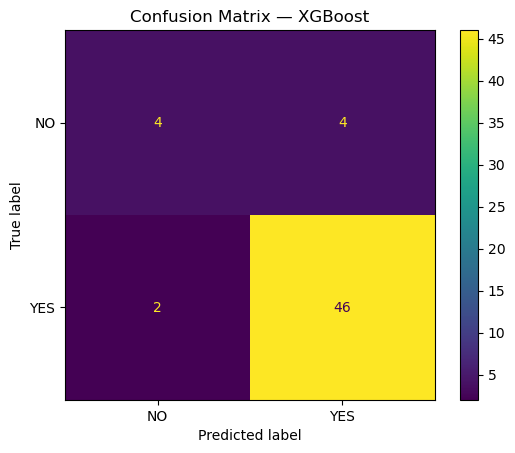

In [62]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

if task_type == "classification":
    display_labels = (
        target_encoder.classes_
        if target_encoder is not None
        else None
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        final_evaluation["predictions"],
        display_labels=display_labels
    )

    plt.title(
        f"Confusion Matrix — {final_model_name}"
    )

    plt.show()

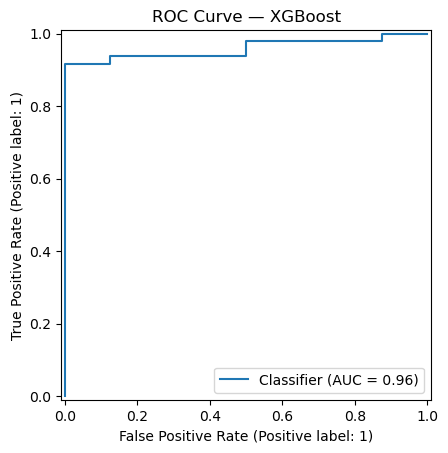

In [63]:
from sklearn.metrics import RocCurveDisplay

if (
    task_type == "classification"
    and number_of_classes == 2
    and final_evaluation[
        "probabilities"
    ] is not None
):
    positive_probabilities = (
        final_evaluation[
            "probabilities"
        ][:, 1]
    )

    RocCurveDisplay.from_predictions(
        y_test,
        positive_probabilities
    )

    plt.title(
        f"ROC Curve — {final_model_name}"
    )

    plt.show()

In [65]:
# ROC-AUC measures how well the model ranks positive examples above negative examples across all possible thresholds.

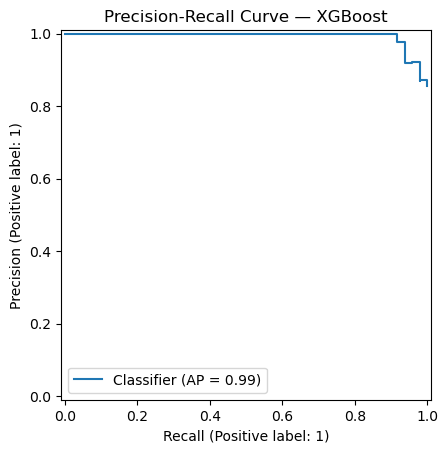

In [66]:
from sklearn.metrics import (
    PrecisionRecallDisplay
)

if (
    task_type == "classification"
    and number_of_classes == 2
    and final_evaluation[
        "probabilities"
    ] is not None
):
    positive_probabilities = (
        final_evaluation[
            "probabilities"
        ][:, 1]
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        positive_probabilities
    )

    plt.title(
        f"Precision-Recall Curve — "
        f"{final_model_name}"
    )

    plt.show()

In [67]:
# Precision-recall curves are especially helpful when the target classes are imbalanced.

In [68]:
if task_type == "regression":
    regression_predictions = (
        final_evaluation["predictions"]
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        regression_predictions
    )

    minimum_value = min(
        y_test.min(),
        regression_predictions.min()
    )

    maximum_value = max(
        y_test.max(),
        regression_predictions.max()
    )

    plt.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value]
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(
        f"Actual vs Predicted — "
        f"{final_model_name}"
    )

    plt.show()

In [69]:
prediction_preview = X_test.copy()

if task_type == "classification":
    encoded_predictions = (
        final_evaluation["predictions"]
    )

    prediction_preview[
        "Actual"
    ] = target_encoder.inverse_transform(
        y_test.to_numpy()
    )

    prediction_preview[
        "Prediction"
    ] = target_encoder.inverse_transform(
        encoded_predictions
    )

    if (
        final_evaluation[
            "probabilities"
        ] is not None
        and number_of_classes == 2
    ):
        prediction_preview[
            "Probability_Positive_Class"
        ] = final_evaluation[
            "probabilities"
        ][:, 1]

else:
    prediction_preview[
        "Actual"
    ] = y_test

    prediction_preview[
        "Prediction"
    ] = final_evaluation[
        "predictions"
    ]

display(
    prediction_preview.head(10)
)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,Actual,Prediction,Probability_Positive_Class
217,F,77,1,1,1,2,2,2,2,2,2,1,1,1,2,YES,YES,0.997166
25,M,65,1,2,2,1,1,2,1,2,2,2,2,2,2,YES,YES,0.994802
13,M,58,2,1,1,1,1,2,2,2,2,2,2,1,2,YES,YES,0.980254
105,F,60,2,2,2,2,2,1,2,2,2,1,1,2,2,YES,YES,0.998808
22,F,21,2,1,1,1,2,2,2,1,1,1,2,1,1,NO,YES,0.767295
63,F,68,1,1,2,1,2,1,2,2,2,1,1,2,1,YES,YES,0.986075
58,M,47,1,2,1,2,2,2,1,2,1,1,2,2,2,YES,YES,0.988196
157,F,55,1,1,1,2,2,2,2,2,2,1,1,1,2,YES,YES,0.995319
155,F,56,1,1,2,2,2,2,2,2,2,1,2,2,2,YES,YES,0.995331
21,F,64,1,2,2,2,1,1,2,2,1,2,1,2,1,YES,YES,0.976453


In [70]:
print(
    "Final model:",
    final_model_name
)

print(
    "Cross-validation score:",
    round(final_cv_score, 4)
)

print("\nTest metrics:")

for metric_name, metric_value in (
    final_evaluation["metrics"].items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Final model: XGBoost
Cross-validation score: 0.79

Test metrics:
Accuracy: 0.8929
Balanced Accuracy: 0.7292
Precision Macro: 0.7933
Recall Macro: 0.7292
F1 Macro: 0.7551
ROC-AUC: 0.9583


In [71]:
# Convert values to JSON safe formats

In [72]:
from datetime import datetime

def make_json_safe(value):
    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple, set)):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    return value

In [73]:
def save_automl_artifacts(
    csv_path,
    target_column,
    task_type,
    dataset_summary,
    column_report,
    cleaning_actions,
    X,
    X_train,
    X_test,
    numerical_columns,
    categorical_columns,
    target_information,
    baseline_leaderboard,
    baseline_failures,
    tuned_leaderboard,
    tuning_failures,
    final_model_name,
    final_pipeline,
    final_parameters,
    final_cv_score,
    final_evaluation,
    target_encoder,
    prediction_preview,
    selection_method="tuned",
    output_root="automl_runs"
):
    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )

    dataset_name = Path(csv_path).stem

    run_directory = (
        Path(output_root)
        / f"{dataset_name}_{timestamp}"
    )

    run_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    # Save preprocessing + model
    model_path = (
        run_directory
        / "model_pipeline.joblib"
    )

    joblib.dump(
        final_pipeline,
        model_path
    )

    # Save target encoder for classification
    encoder_path = None

    if target_encoder is not None:
        encoder_path = (
            run_directory
            / "target_encoder.joblib"
        )

        joblib.dump(
            target_encoder,
            encoder_path
        )

    input_schema = {
        "feature_columns": X.columns.tolist(),

        "feature_dtypes": {
            column: str(X[column].dtype)
            for column in X.columns
        },

        "numerical_columns": numerical_columns,

        "categorical_columns": (
            categorical_columns
        ),

        "feature_count": int(X.shape[1])
    }

    schema_path = (
        run_directory
        / "input_schema.json"
    )

    with open(
        schema_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            make_json_safe(input_schema),
            file,
            indent=4
        )

    metadata = {
        "dataset_name": Path(csv_path).name,
        "target_column": target_column,
        "task_type": task_type,
        "final_model": final_model_name,
        "selection_method": selection_method,
        "final_cv_score": final_cv_score,
        "final_parameters": final_parameters,
        "target_information": (
            target_information
        ),
        "dataset_summary": dataset_summary,
        "cleaning_actions": cleaning_actions,
        "training_rows": int(
            X_train.shape[0]
        ),
        "testing_rows": int(
            X_test.shape[0]
        ),
        "random_state": RANDOM_STATE,
        "created_at": datetime.now().isoformat()
    }

    metadata_path = (
        run_directory
        / "metadata.json"
    )

    with open(
        metadata_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            make_json_safe(metadata),
            file,
            indent=4
        )

    metrics_path = (
        run_directory
        / "test_metrics.json"
    )

    with open(
        metrics_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            make_json_safe(
                final_evaluation["metrics"]
            ),
            file,
            indent=4
        )

    column_report.to_csv(
        run_directory / "column_report.csv"
    )

    baseline_leaderboard.to_csv(
        run_directory
        / "baseline_leaderboard.csv",
        index=False
    )

    if (
        baseline_failures is not None
        and not baseline_failures.empty
    ):
        baseline_failures.to_csv(
            run_directory
            / "baseline_failures.csv",
            index=False
        )

    if (
        tuned_leaderboard is not None
        and not tuned_leaderboard.empty
    ):
        tuned_leaderboard.to_csv(
            run_directory
            / "tuned_leaderboard.csv",
            index=False
        )

    if (
        tuning_failures is not None
        and not tuning_failures.empty
    ):
        tuning_failures.to_csv(
            run_directory
            / "tuning_failures.csv",
            index=False
        )

    if (
        task_type == "classification"
        and "classification_report"
        in final_evaluation
    ):
        final_evaluation[
            "classification_report"
        ].to_csv(
            run_directory
            / "classification_report.csv"
        )

    prediction_preview.to_csv(
        run_directory
        / "prediction_preview.csv",
        index=False
    )

    artifact_paths = {
        "run_directory": run_directory,
        "model": model_path,
        "encoder": encoder_path,
        "schema": schema_path,
        "metadata": metadata_path,
        "metrics": metrics_path
    }

    return artifact_paths

In [74]:
artifact_paths = save_automl_artifacts(
    csv_path=CSV_PATH,

    target_column=TARGET_COLUMN,

    task_type=task_type,

    dataset_summary=dataset_summary,

    column_report=column_report,

    cleaning_actions=cleaning_actions,

    X=X,

    X_train=X_train,

    X_test=X_test,

    numerical_columns=numerical_columns,

    categorical_columns=categorical_columns,

    target_information=target_information,

    baseline_leaderboard=(
        baseline_leaderboard
    ),

    baseline_failures=baseline_failures,

    tuned_leaderboard=tuned_leaderboard,

    tuning_failures=tuning_failures,

    final_model_name=final_model_name,

    final_pipeline=final_pipeline,

    final_parameters=final_parameters,

    final_cv_score=final_cv_score,

    final_evaluation=final_evaluation,

    target_encoder=target_encoder,

    prediction_preview=prediction_preview
)

In [75]:
for artifact_name, artifact_path in (
    artifact_paths.items()
):
    print(
        f"{artifact_name}: {artifact_path}"
    )

run_directory: automl_runs\survey lung cancer_20260722_112053
model: automl_runs\survey lung cancer_20260722_112053\model_pipeline.joblib
encoder: automl_runs\survey lung cancer_20260722_112053\target_encoder.joblib
schema: automl_runs\survey lung cancer_20260722_112053\input_schema.json
metadata: automl_runs\survey lung cancer_20260722_112053\metadata.json
metrics: automl_runs\survey lung cancer_20260722_112053\test_metrics.json


In [76]:
def load_automl_artifacts(
    run_directory
):
    run_directory = Path(
        run_directory
    )

    pipeline = joblib.load(
        run_directory
        / "model_pipeline.joblib"
    )

    encoder_path = (
        run_directory
        / "target_encoder.joblib"
    )

    target_encoder = None

    if encoder_path.exists():
        target_encoder = joblib.load(
            encoder_path
        )

    with open(
        run_directory / "metadata.json",
        "r",
        encoding="utf-8"
    ) as file:
        metadata = json.load(file)

    with open(
        run_directory / "input_schema.json",
        "r",
        encoding="utf-8"
    ) as file:
        schema = json.load(file)

    return {
        "pipeline": pipeline,
        "target_encoder": target_encoder,
        "metadata": metadata,
        "schema": schema
    }

In [77]:
def predict_with_saved_automl(
    new_data,
    loaded_artifacts
):
    if not isinstance(
        new_data,
        pd.DataFrame
    ):
        raise TypeError(
            "new_data must be a pandas DataFrame."
        )

    pipeline = loaded_artifacts[
        "pipeline"
    ]

    target_encoder = loaded_artifacts[
        "target_encoder"
    ]

    metadata = loaded_artifacts[
        "metadata"
    ]

    expected_columns = loaded_artifacts[
        "schema"
    ]["feature_columns"]

    missing_columns = (
        set(expected_columns)
        - set(new_data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    validated_data = new_data[
        expected_columns
    ].copy()

    predictions = pipeline.predict(
        validated_data
    )

    if (
        metadata["task_type"]
        == "classification"
    ):
        if target_encoder is None:
            raise RuntimeError(
                "Target encoder is missing."
            )

        decoded_predictions = (
            target_encoder.inverse_transform(
                predictions.astype(int)
            )
        )

        result = pd.DataFrame({
            "Prediction": (
                decoded_predictions
            )
        })

        if hasattr(
            pipeline,
            "predict_proba"
        ):
            probabilities = (
                pipeline.predict_proba(
                    validated_data
                )
            )

            for class_index, class_name in (
                enumerate(
                    target_encoder.classes_
                )
            ):
                result[
                    f"Probability_{class_name}"
                ] = probabilities[
                    :,
                    class_index
                ]

        return result

    return pd.DataFrame({
        "Prediction": predictions
    })

In [78]:
loaded_artifacts = load_automl_artifacts(
    artifact_paths["run_directory"]
)

sample_data = X_test.head(3).copy()

saved_model_predictions = (
    predict_with_saved_automl(
        new_data=sample_data,
        loaded_artifacts=loaded_artifacts
    )
)

display(saved_model_predictions)

,Prediction,Probability_NO,Probability_YES
0,YES,0.002834,0.997166
1,YES,0.005198,0.994802
2,YES,0.019746,0.980254


In [79]:
def fit_best_baseline_model(
    baseline_leaderboard,
    model_pipelines,
    X_train,
    y_train,
    task_type
):
    excluded_models = {
        "Dummy Classifier",
        "Dummy Regressor"
    }

    eligible_rows = baseline_leaderboard[
        ~baseline_leaderboard["Model"].isin(
            excluded_models
        )
    ]

    if eligible_rows.empty:
        raise RuntimeError(
            "No successful baseline model is available."
        )

    model_name = eligible_rows.iloc[0][
        "Model"
    ]

    pipeline = clone(
        model_pipelines[model_name]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    if task_type == "classification":
        cv_score = float(
            eligible_rows.iloc[0][
                "F1 Macro"
            ]
        )

    else:
        cv_score = float(
            eligible_rows.iloc[0]["RMSE"]
        )

    parameters = pipeline.named_steps[
        "model"
    ].get_params()

    return (
        model_name,
        pipeline,
        parameters,
        cv_score
    )

In [80]:
def run_automl(
    csv_path,
    target_column,
    task="auto",
    columns_to_drop=None,
    tuning_mode="balanced",
    test_size=TEST_SIZE,
    output_root="automl_runs"
):
    if task not in {
        "auto",
        "classification",
        "regression"
    }:
        raise ValueError(
            "task must be 'auto', "
            "'classification', or 'regression'."
        )

    print("1. Loading dataset...")

    dataframe = load_dataset(
        csv_path
    )

    dataset_summary, column_report = (
        inspect_dataset(
            dataframe=dataframe,
            target_column=target_column
        )
    )

    print("2. Cleaning dataset...")

    (
        cleaned_dataframe,
        cleaning_actions
    ) = clean_dataset(
        dataframe=dataframe,
        target_column=target_column,
        columns_to_drop=columns_to_drop
    )

    X, original_target = (
        separate_features_and_target(
            dataframe=cleaned_dataframe,
            target_column=target_column
        )
    )

    detected_task = detect_task_type(
        original_target
    )

    task_type = (
        detected_task
        if task == "auto"
        else task
    )

    (
        y,
        target_encoder,
        target_information
    ) = prepare_target(
        target=original_target,
        task_type=task_type
    )

    (
        numerical_columns,
        categorical_columns
    ) = detect_feature_types(
        X
    )

    print(
        f"3. Detected task: {task_type}"
    )

    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = split_dataset(
        X=X,
        y=y,
        task_type=task_type,
        test_size=test_size
    )

    number_of_classes = None

    if task_type == "classification":
        number_of_classes = int(
            y_train.nunique()
        )

    preprocessor = build_preprocessor(
        numerical_columns=(
            numerical_columns
        ),
        categorical_columns=(
            categorical_columns
        )
    )

    candidate_models = (
        get_candidate_models(
            task_type=task_type,
            number_of_classes=(
                number_of_classes
            ),
            number_of_rows=len(X_train)
        )
    )

    model_pipelines = (
        create_model_pipelines(
            preprocessor=preprocessor,
            models=candidate_models
        )
    )

    cv_strategy = create_cv_strategy(
        y=y_train,
        task_type=task_type
    )

    scoring_configuration = (
        get_scoring_configuration(
            task_type=task_type,
            number_of_classes=(
                number_of_classes
            )
        )
    )

    print(
        "4. Evaluating baseline models..."
    )

    (
        baseline_leaderboard,
        baseline_failures
    ) = evaluate_baseline_models(
        model_pipelines=model_pipelines,
        X_train=X_train,
        y_train=y_train,
        cv_strategy=cv_strategy,
        scoring_configuration=(
            scoring_configuration
        ),
        task_type=task_type
    )

    tuning_budget = get_tuning_budget(
        tuning_mode
    )

    top_model_names = select_top_models(
        leaderboard=baseline_leaderboard,
        number_of_models=(
            tuning_budget[
                "maximum_models"
            ]
        )
    )

    parameter_spaces = (
        get_parameter_spaces(
            task_type
        )
    )

    tuned_leaderboard = pd.DataFrame()
    tuning_failures = pd.DataFrame()
    selection_method = "tuned"

    print(
        "5. Tuning strongest models..."
    )

    try:
        (
            tuned_leaderboard,
            tuned_searches,
            tuning_failures
        ) = tune_selected_models(
            selected_model_names=(
                top_model_names
            ),
            model_pipelines=(
                model_pipelines
            ),
            parameter_spaces=(
                parameter_spaces
            ),
            X_train=X_train,
            y_train=y_train,
            cv_strategy=cv_strategy,
            scoring_configuration=(
                scoring_configuration
            ),
            task_type=task_type,
            iterations_per_model=(
                tuning_budget[
                    "iterations_per_model"
                ]
            )
        )

        (
            final_model_name,
            final_pipeline,
            final_parameters,
            final_cv_score
        ) = select_final_model(
            tuned_leaderboard=(
                tuned_leaderboard
            ),
            tuned_searches=(
                tuned_searches
            ),
            task_type=task_type
        )

    except Exception as tuning_error:
        print(
            "Tuning was unsuccessful. "
            "Using best baseline model."
        )

        selection_method = (
            "baseline_fallback"
        )

        tuning_failures = pd.DataFrame([
            {
                "Model": "Tuning stage",
                "Error": str(tuning_error)
            }
        ])

        (
            final_model_name,
            final_pipeline,
            final_parameters,
            final_cv_score
        ) = fit_best_baseline_model(
            baseline_leaderboard=(
                baseline_leaderboard
            ),
            model_pipelines=(
                model_pipelines
            ),
            X_train=X_train,
            y_train=y_train,
            task_type=task_type
        )

    print(
        f"6. Evaluating final model: "
        f"{final_model_name}"
    )

    final_evaluation = (
        evaluate_final_model(
            final_pipeline=final_pipeline,
            X_test=X_test,
            y_test=y_test,
            task_type=task_type,
            target_encoder=(
                target_encoder
            )
        )
    )

    prediction_preview = X_test.copy()

    if task_type == "classification":
        prediction_preview[
            "Actual"
        ] = target_encoder.inverse_transform(
            y_test.to_numpy()
        )

        prediction_preview[
            "Prediction"
        ] = target_encoder.inverse_transform(
            final_evaluation[
                "predictions"
            ].astype(int)
        )

    else:
        prediction_preview[
            "Actual"
        ] = y_test.to_numpy()

        prediction_preview[
            "Prediction"
        ] = final_evaluation[
            "predictions"
        ]

    print("7. Saving artifacts...")

    artifact_paths = (
        save_automl_artifacts(
            csv_path=csv_path,
            target_column=target_column,
            task_type=task_type,
            dataset_summary=(
                dataset_summary
            ),
            column_report=column_report,
            cleaning_actions=(
                cleaning_actions
            ),
            X=X,
            X_train=X_train,
            X_test=X_test,
            numerical_columns=(
                numerical_columns
            ),
            categorical_columns=(
                categorical_columns
            ),
            target_information=(
                target_information
            ),
            baseline_leaderboard=(
                baseline_leaderboard
            ),
            baseline_failures=(
                baseline_failures
            ),
            tuned_leaderboard=(
                tuned_leaderboard
            ),
            tuning_failures=(
                tuning_failures
            ),
            final_model_name=(
                final_model_name
            ),
            final_pipeline=(
                final_pipeline
            ),
            final_parameters=(
                final_parameters
            ),
            final_cv_score=(
                final_cv_score
            ),
            final_evaluation=(
                final_evaluation
            ),
            target_encoder=(
                target_encoder
            ),
            prediction_preview=(
                prediction_preview
            ),
            selection_method=(
                selection_method
            ),
            output_root=output_root
        )
    )

    print("AutoML run completed.")

    return {
        "task_type": task_type,
        "final_model_name": (
            final_model_name
        ),
        "final_pipeline": final_pipeline,
        "final_cv_score": final_cv_score,
        "final_parameters": (
            final_parameters
        ),
        "final_evaluation": (
            final_evaluation
        ),
        "baseline_leaderboard": (
            baseline_leaderboard
        ),
        "tuned_leaderboard": (
            tuned_leaderboard
        ),
        "target_encoder": target_encoder,
        "artifact_paths": artifact_paths,
        "dataset_summary": (
            dataset_summary
        ),
        "cleaning_actions": (
            cleaning_actions
        )
    }

In [81]:
automl_result = run_automl(
    csv_path="survey lung cancer.csv",
    target_column="LUNG_CANCER",
    task="auto",
    tuning_mode="fast"
)

1. Loading dataset...
2. Cleaning dataset...
3. Detected task: classification
4. Evaluating baseline models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating KNN...
Evaluating XGBoost...
5. Tuning strongest models...

Tuning XGBoost...
Testing 10 parameter combinations.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
6. Evaluating final model: XGBoost
7. Saving artifacts...
AutoML run completed.


In [82]:
print(
    "Selected model:",
    automl_result[
        "final_model_name"
    ]
)

print(
    "CV score:",
    round(
        automl_result[
            "final_cv_score"
        ],
        4
    )
)

display(
    pd.DataFrame([
        automl_result[
            "final_evaluation"
        ]["metrics"]
    ]).round(4)
)

Selected model: XGBoost
CV score: 0.7851


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC
0,0.8929,0.7292,0.7933,0.7292,0.7551,0.9401


In [84]:
automl_result = run_automl(
    csv_path="heart.csv",
    target_column="HeartDisease"
)

1. Loading dataset...
2. Cleaning dataset...
3. Detected task: classification
4. Evaluating baseline models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating KNN...
Evaluating XGBoost...
5. Tuning strongest models...

Tuning XGBoost...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tuning Random Forest...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits
6. Evaluating final model: XGBoost
7. Saving artifacts...
AutoML run completed.


In [85]:
print(
    "Selected model:",
    automl_result[
        "final_model_name"
    ]
)

print(
    "CV score:",
    round(
        automl_result[
            "final_cv_score"
        ],
        4
    )
)

display(
    pd.DataFrame([
        automl_result[
            "final_evaluation"
        ]["metrics"]
    ]).round(4)
)

Selected model: XGBoost
CV score: 0.8696


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC
0,0.8913,0.89,0.89,0.89,0.89,0.935


In [87]:
automl_result = run_automl(
    csv_path="insurance.csv",
    target_column="charges"
)

1. Loading dataset...
2. Cleaning dataset...
3. Detected task: regression
4. Evaluating baseline models...
Evaluating Dummy Regressor...
Evaluating Ridge Regression...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating XGBoost...
Evaluating KNN...
5. Tuning strongest models...

Tuning XGBoost...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tuning Random Forest...
Testing 25 parameter combinations.
Fitting 5 folds for each of 25 candidates, totalling 125 fits
6. Evaluating final model: XGBoost
7. Saving artifacts...
AutoML run completed.


In [88]:
print(
    "Selected model:",
    automl_result[
        "final_model_name"
    ]
)

print(
    "CV score:",
    round(
        automl_result[
            "final_cv_score"
        ],
        4
    )
)

display(
    pd.DataFrame([
        automl_result[
            "final_evaluation"
        ]["metrics"]
    ]).round(4)
)

Selected model: XGBoost
CV score: 4573.4427


,MAE,RMSE,R2
0,2501.0069,4287.3468,0.9
